# Part 1: Experiment Tracking with MLflow

In [21]:
import mlflow
import numpy as np
import joblib
import time
import os
from pathlib import Path
import requests
import polars as pl
from mlflow.tracking import MlflowClient
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import(
    mean_absolute_error, r2_score
)

Reusing Code from Assignment 2 to Download, Clean and Transform Data for Splitting

In [22]:
# Define URLs for required files
taxi_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

# Create data/raw directory if it doesn't exist
BASE_DIR = Path.cwd().resolve()
data_dir = BASE_DIR / "data" / "raw"
data_dir.mkdir(parents=True, exist_ok=True)

# Defines File paths for downloaded data
taxi_path = data_dir / "yellow_tripdata_2024-01.parquet"
zone_path = data_dir / "taxi_zone_lookup.csv"

# Download Files and write to specified paths
def download_file(url, path):
    if path.exists():
        return
     
    with requests.get(url, stream=True, timeout=30) as r:
        r.raise_for_status()
        with open(path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

download_file(taxi_url, taxi_path)
download_file(zone_url, zone_path)
print("\nFiles downloaded successfully!")


Files downloaded successfully!


In [23]:
# Load Taxi Data with Polars
df = pl.read_parquet(taxi_path)

# Load Zone Lookup Data with Polars
df_zones = pl.read_csv(zone_path)

# Remove rows with nulls
def remove_nulls(df):
    num_rows = df.height

    critical_columns = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", 
                    "DOLocationID", "fare_amount"]
    
    df = df.drop_nulls(critical_columns)

    removed_nulls = num_rows - df.height
    return df, removed_nulls

# Filter out invalid trips tracking reasons for removal
def filter_trips(df):
    current_rows = df.height

    df = df.filter(pl.col("trip_distance") > 0)
    invalid_distance = current_rows - df.height
    current_rows = df.height

    df = df.filter(pl.col("fare_amount") > 0)
    negative_fare = current_rows - df.height
    current_rows = df.height

    df = df.filter(pl.col("fare_amount") <= 500)
    exceeding_max = current_rows - df.height

    return df, invalid_distance, negative_fare, exceeding_max

# Filter out trips with dropoff before pickup
def filter_time(df):
    num_rows = df.height

    df = df.filter(pl.col("tpep_dropoff_datetime") > pl.col("tpep_pickup_datetime"))

    removed_time = num_rows - df.height
    return df, removed_time

# Print summary of removals
def save_and_print(df, total_removed, removed_nulls, invalid_distance, negative_fare, exceeding_max, removed_time):
    print("\n=== Cleaned Dataset Summary ===")
    print(f"Total rows removed: {total_removed:,}")
    print(f"Removed null values: {removed_nulls:,}")
    print(f"Removed invalid distances: {invalid_distance:,}")
    print(f"Removed negative fares: {negative_fare:,}")
    print(f"Removed exceeding $500: {exceeding_max:,}")
    print(f"Removed invalid times: {removed_time:,}")

original_rows = df.height

df, removed_nulls = remove_nulls(df)
df, invalid_distance, negative_fare, exceeding_max = filter_trips(df)
df, removed_time = filter_time(df)

total_removed = original_rows - df.height

save_and_print(df, total_removed, removed_nulls, invalid_distance, negative_fare, exceeding_max, removed_time)


=== Cleaned Dataset Summary ===
Total rows removed: 95,052
Removed null values: 0
Removed invalid distances: 60,371
Removed negative fares: 34,539
Removed exceeding $500: 30
Removed invalid times: 112


In [24]:
# Filter to credit card payments only (payment_type == 1)
df = df.filter(pl.col("payment_type") == 1)
print(df.shape)

(2298347, 19)


In [25]:
# Feature Engineering - Temporal Features
df = df.with_columns([
    pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),

    # Adjusting weekday to have Monday=0, Sunday=6 by minusing 1
    (pl.col("tpep_pickup_datetime").dt.weekday() - 1).alias("pickup_day_of_week"),
])

df = df.with_columns(
    (pl.col("pickup_day_of_week") >= 5).alias("is_weekend")
)

In [26]:
# Feature Engineering - Trip Features
df = df.with_columns([
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_seconds() / 60)
    .alias("trip_duration_minutes"),

    pl.col("trip_distance").log1p().alias("log_trip_distance")
])

df = df.with_columns([
    (pl.when(pl.col("trip_duration_minutes") > 0)
    .then(pl.col("trip_distance") / (pl.col("trip_duration_minutes") / 60))
    .otherwise(0)
    ).alias("trip_speed_mph")
])

In [27]:
# Feature Engineering - Fare Features
df = df.with_columns([
    # Ensuring we don't divide by zero for distance by using a conditional expression
    (pl.when(pl.col("trip_distance") > 0)
    .then(pl.col("fare_amount") / pl.col("trip_distance"))
    .otherwise(0)
    ).alias("fare_per_mile"),
    
    # Ensuring we don't divide by zero for duration by using a conditional expression
    (pl.when(pl.col("trip_duration_minutes") > 0)
    .then(pl.col("fare_amount") / pl.col("trip_duration_minutes"))
    .otherwise(0)
    ).alias("fare_per_minute")
])

In [28]:
# Feature Engineering - Zone Features
# Join to get pickup borough
df = df.join(
    df_zones.select(["LocationID", "Borough"])
    .rename({
        "LocationID": "PULocationID", 
        "Borough": "pickup_borough"
    }), 
    on="PULocationID", 
    how="left"
)

# Join to get dropoff borough
df = df.join(
    df_zones.select(["LocationID", "Borough"])
    .rename({
        "LocationID": "DOLocationID", 
        "Borough": "dropoff_borough"
    }), 
    on="DOLocationID", 
    how="left"
)

# Define the Encoder to be used for both pickup and dropoff boroughs
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# One-hot encode the pickup borough columns
encoded = encoder.fit_transform(df.select("pickup_borough").to_numpy())
encoded_pickup = pl.DataFrame(encoded, 
                              schema = encoder.get_feature_names_out(["pickup_borough"])
                              .tolist())
df = df.hstack(encoded_pickup)

# One-hot encode the dropoff borough columns
encoded = encoder.fit_transform(df.select("dropoff_borough").to_numpy())
encoded_dropoff = pl.DataFrame(encoded, 
                               schema = encoder.get_feature_names_out(["dropoff_borough"])
                               .tolist())
df = df.hstack(encoded_dropoff)

print(f"\nDataFrame shape after all feature engineering: {df.shape}")
print(f"Columns: {df.columns}")


DataFrame shape after all feature engineering: (2298347, 45)
Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'log_trip_distance', 'trip_speed_mph', 'fare_per_mile', 'fare_per_minute', 'pickup_borough', 'dropoff_borough', 'pickup_borough_Bronx', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Bronx', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unkn

In [29]:
# Target 1: tip_amount (already a column)
# Target 2: high_tip – 1 if tip_amount > 20% of fare_amount
df = df.with_columns([
    pl.when(pl.col("tip_amount") > (pl.col("fare_amount") * 0.20))
    .then(1)
    .otherwise(0)
    .alias("high_tip")
])

# Class distribution
high_tip_counts = df["high_tip"].value_counts().sort("high_tip")
print("\nhigh_tip class distribution:")
print(high_tip_counts)


high_tip class distribution:
shape: (2, 2)
┌──────────┬─────────┐
│ high_tip ┆ count   │
│ ---      ┆ ---     │
│ i32      ┆ u32     │
╞══════════╪═════════╡
│ 0        ┆ 553151  │
│ 1        ┆ 1745196 │
└──────────┴─────────┘


In [30]:
# Convert to Pandas for splitting, scaling and modeling
df = df.to_pandas()
print(df.shape)
print(f'Original Columns: {df.columns.tolist()}')

# Identify datetime columns for exclusion
datetime_cols = df.select_dtypes(include='datetime').columns.tolist()

# Identify just the pickup_borough and dropoff_borough columns for exclusion since we have already one-hot encoded them
borough_cols = ["pickup_borough", "dropoff_borough"]

df = df.drop(columns=datetime_cols + borough_cols)
print(df.shape)
print(f'Remaining Columns: {df.columns.tolist()}')

(2298347, 46)
Original Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'log_trip_distance', 'trip_speed_mph', 'fare_per_mile', 'fare_per_minute', 'pickup_borough', 'dropoff_borough', 'pickup_borough_Bronx', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Bronx', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unknown', 'high_tip']
(2298347, 42)
Remaini

In [31]:
# Define RANDOM_STATE for reproducibility
RANDOM_STATE = 42

target_columns = ["tip_amount", "high_tip"]

X = df.drop(columns=target_columns)
y_reg = df["tip_amount"]    # regression target
y_clf = df["high_tip"]     # classification target

# Step 1: split off training set (70 %)
X_train, X_temp, y_reg_train, y_reg_temp, y_clf_train, y_clf_temp = train_test_split(
    X, y_reg, y_clf,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# Step 2: split remaining into test (15 %) and validation (15 %)
X_test, X_val, y_reg_test, y_reg_val, y_clf_test, y_clf_val = train_test_split(
    X_temp, y_reg_temp, y_clf_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_clf_temp
)

In [32]:
# Identify numeric and categorical features
numeric_features = [col for col in X.columns if X[col].dtype in ['int8', 'int32', 'int64', 'float64', 'bool']]
categorical_features = [col for col in X.columns if X[col].dtype == 'object']

print(f"\nNumeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# Define numeric transformer with imputation and scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Define categorical transformer with imputation and one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine transformers into a ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


Numeric features: ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'log_trip_distance', 'trip_speed_mph', 'fare_per_mile', 'fare_per_minute', 'pickup_borough_Bronx', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Bronx', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unknown']
Categorical features: ['store_and_fwd_flag']


In [33]:
# Print Number of samples in each split
print("=== Split Sizes ===")
print(f"  Train      : {X_train.shape[0]:>8,}  ({X_train.shape[0]/X.shape[0]:.1%})")
print(f"  Validation : {X_val.shape[0]:>8,}  ({X_val.shape[0]/X.shape[0]:.1%})")
print(f"  Test       : {X_test.shape[0]:>8,}  ({X_test.shape[0]/X.shape[0]:.1%})")

# Print high_tip class distribution in each split
print("\n=== high_tip Class Distribution ===")
print("\nTrain:")
print(y_clf_train.value_counts(normalize=True).sort_index())

print("\nValidation:")
print(y_clf_val.value_counts(normalize=True).sort_index())

print("\nTest:")
print(y_clf_test.value_counts(normalize=True).sort_index())

=== Split Sizes ===
  Train      : 1,608,842  (70.0%)
  Validation :  344,753  (15.0%)
  Test       :  344,752  (15.0%)

=== high_tip Class Distribution ===

Train:
high_tip
0    0.240673
1    0.759327
Name: proportion, dtype: float64

Validation:
high_tip
0    0.240674
1    0.759326
Name: proportion, dtype: float64

Test:
high_tip
0    0.240674
1    0.759326
Name: proportion, dtype: float64


In [34]:
# ===== Feature Summary =====
print("\n=== Feature Summary ===")

print(f"\nTotal features used for modeling: {len(X.columns)}")

print("\nNumeric Features:")
for col in numeric_features:
    print(f"  - {col} ({X[col].dtype})")

print("\nCategorical Features:")
for col in categorical_features:
    print(f"  - {col} ({X[col].dtype})")


# ===== Excluded Features =====
print("\n=== Excluded Features ===")

print("\nTarget Variables (excluded from X):")
for col in target_columns:
    print(f"  - {col} (target variable for prediction)")

print("\nDatetime Features:")
for col in datetime_cols:
    print(f"  - {col} (excluded because sklearn models cannot directly use datetime objects)")

print("\nCategorical Borough Features:")
for col in borough_cols:
    print(f"  - {col} (excluded because they are already one-hot encoded)")


=== Feature Summary ===

Total features used for modeling: 40

Numeric Features:
  - VendorID (int32)
  - passenger_count (int64)
  - trip_distance (float64)
  - RatecodeID (int64)
  - PULocationID (int32)
  - DOLocationID (int32)
  - payment_type (int64)
  - fare_amount (float64)
  - extra (float64)
  - mta_tax (float64)
  - tolls_amount (float64)
  - improvement_surcharge (float64)
  - total_amount (float64)
  - congestion_surcharge (float64)
  - Airport_fee (float64)
  - pickup_hour (int8)
  - pickup_day_of_week (int8)
  - is_weekend (bool)
  - trip_duration_minutes (float64)
  - log_trip_distance (float64)
  - trip_speed_mph (float64)
  - fare_per_mile (float64)
  - fare_per_minute (float64)
  - pickup_borough_Bronx (float64)
  - pickup_borough_Brooklyn (float64)
  - pickup_borough_EWR (float64)
  - pickup_borough_Manhattan (float64)
  - pickup_borough_N/A (float64)
  - pickup_borough_Queens (float64)
  - pickup_borough_Staten Island (float64)
  - pickup_borough_Unknown (float64)


In [35]:
# Fit preprocessor on training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test sets
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed!")
print(f"Train shape: {X_train_processed.shape}")
print(f"Validation shape: {X_val_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")

Preprocessing completed!
Train shape: (1608842, 41)
Validation shape: (344753, 41)
Test shape: (344752, 41)


In [36]:
os.makedirs("models", exist_ok=True)

joblib.dump(preprocessor, "models/preprocessor.pkl")

print("\nPreprocessor saved Sucessfully!")


Preprocessor saved Sucessfully!


Retraining Models

In [37]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_reg_train)

# Random Forest Regressor (with reduced complexity for faster training)
rf_reg = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_reg.fit(X_train_processed, y_reg_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Task 1.1: MLflow Setup & Experiment Logging

Setting up Tracking Server & Defining Helper Function for Logging 

In [38]:
# Point to my tracking server
mlflow.set_tracking_uri("http://localhost:5000")

# Create an Experiment
mlflow.set_experiment("taxi-tip-prediction")

# Defining Metric Logging Helper function
def log_metrics(y_true, y_pred):
    mlflow.log_metric("mae", mean_absolute_error(y_true, y_pred))
    mlflow.log_metric("rmse", np.sqrt(mean_absolute_error(y_true, y_pred)))
    mlflow.log_metric("r2", r2_score(y_true, y_pred))
    

Logging Linear Regression Model

In [39]:
# Logging Linear Regression
with mlflow.start_run(run_name="linear-regression"):
    mlflow.log_params({"model_type": "LinearRegression"})

    mlflow.set_tag("model_type", "LinearRegression")
    mlflow.set_tag("dataset_version", "v1")

    preds = lin_reg.predict(X_test_processed)
    log_metrics(y_reg_test, preds)
    
    mlflow.sklearn.log_model(lin_reg, "model")
    
    print("Linear Regression Logged")

2026/04/18 23:26:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 23:27:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression Logged
🏃 View run linear-regression at: http://localhost:5000/#/experiments/1/runs/4fb5da9aeebb4792a974595e942b8a50
🧪 View experiment at: http://localhost:5000/#/experiments/1


Logging Random Forest Model

In [40]:
# Logging Random Forest Regressor
with mlflow.start_run(run_name="random-forest"):
    params = {
        "n_estimators": 30,
        "max_depth": 10,
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": -1
    }
    mlflow.log_params(params)

    mlflow.set_tag("model_type", "RandomForest")
    mlflow.set_tag("dataset_version", "v1")

    preds = rf_reg.predict(X_test_processed)
    log_metrics(y_reg_test, preds)

    mlflow.sklearn.log_model(rf_reg, "model")
    
    print("Random Forest Logged")

2026/04/18 23:27:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 23:27:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Logged
🏃 View run random-forest at: http://localhost:5000/#/experiments/1/runs/ab27ac6e027b480aae094489a768ae8b
🧪 View experiment at: http://localhost:5000/#/experiments/1


Screenshot of MLflow UI showing all Logged Runs

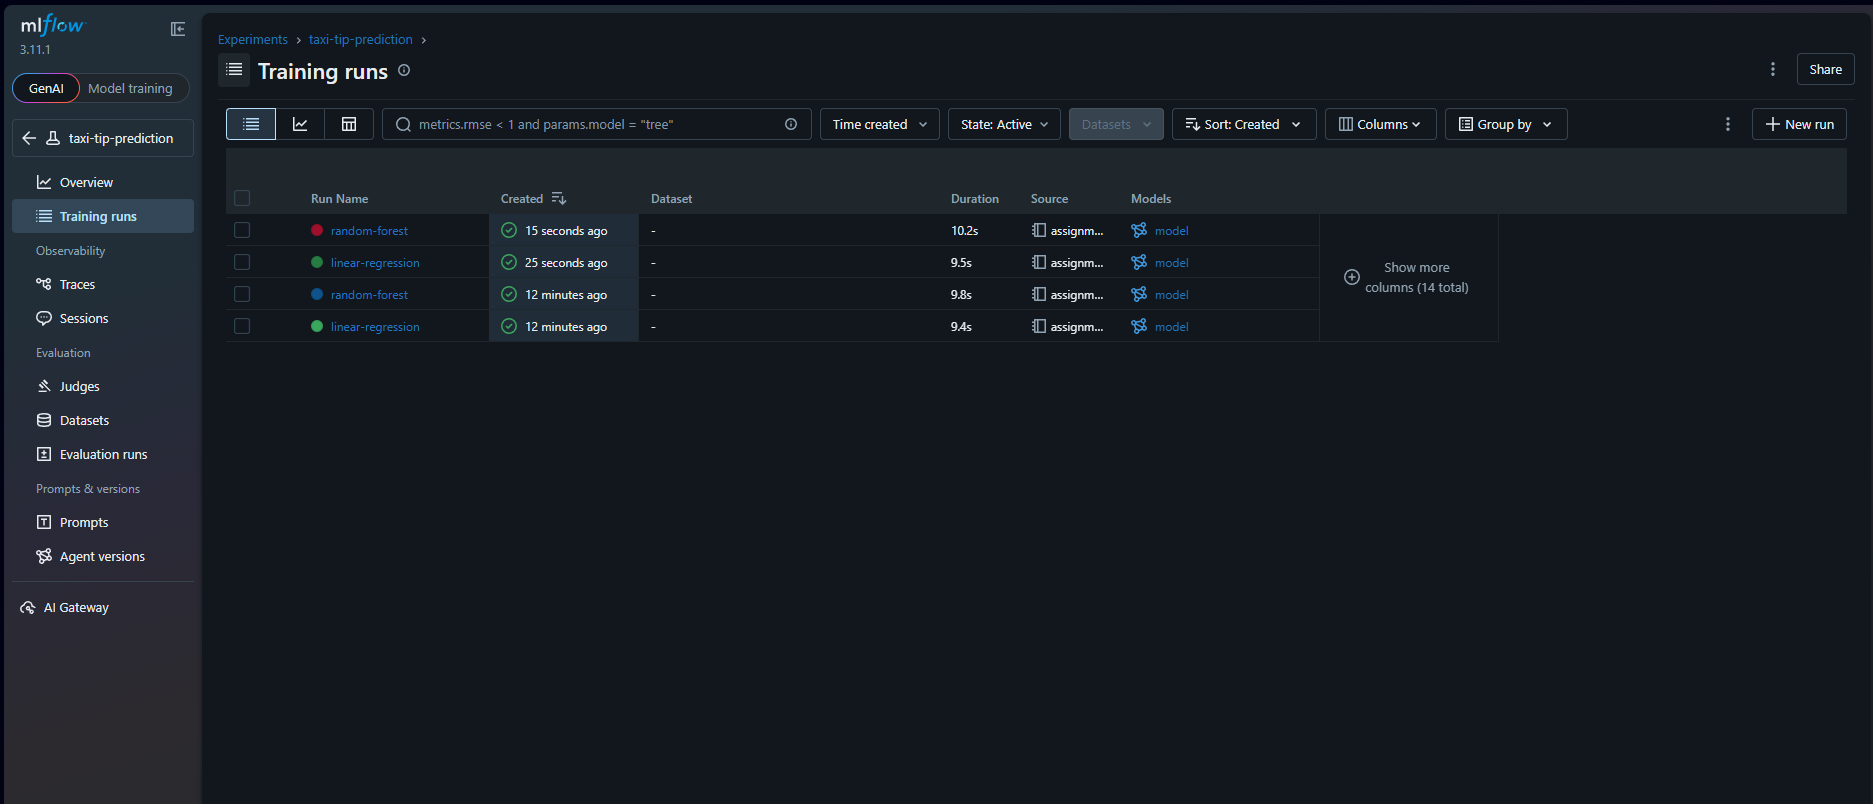

### Task 1.2: Model Comparison & Registry

Comparing all Logged Runs

In [41]:
experiment = mlflow.get_experiment_by_name("taxi-tip-prediction")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

print(runs[["run_id", "tags.model_type", "metrics.mae", "metrics.rmse", "metrics.r2"]])

                              run_id   tags.model_type  metrics.mae  \
0   ab27ac6e027b480aae094489a768ae8b      RandomForest     0.901041   
1   4fb5da9aeebb4792a974595e942b8a50  LinearRegression     0.075032   
2   0f275889716a4c0690ee27731f976cad      RandomForest     0.901041   
3   717435864a0a46748fc983b58946e3d0  LinearRegression     0.075032   
4   3382f264c87f4fc3b97e3fe9a5ee102a      RandomForest     0.901041   
5   c692e90bb1f24ff8944d328c7dd05c4b  LinearRegression     0.075032   
6   f8f9739f8b054aa0bddf91209d729c94      RandomForest     0.901041   
7   3c04a8c3c3da43ec9ae61eff214ad136  LinearRegression     0.075032   
8   77b540cdb30144d18ab4b0693ef481f1      RandomForest     0.901041   
9   ce7540df9bbd43d18a86655088aa206c  LinearRegression     0.075032   
10  18e347e8bd1544e1b29d5f18db21ee8a      RandomForest     0.901041   
11  788e3e2b428d460eb6c2838264b124f4  LinearRegression     0.075032   
12  210a2a2f583b4247a286cf1bb041d2c2      RandomForest     0.901041   
13  6e

Screenshot of MLflow UI Comparison View

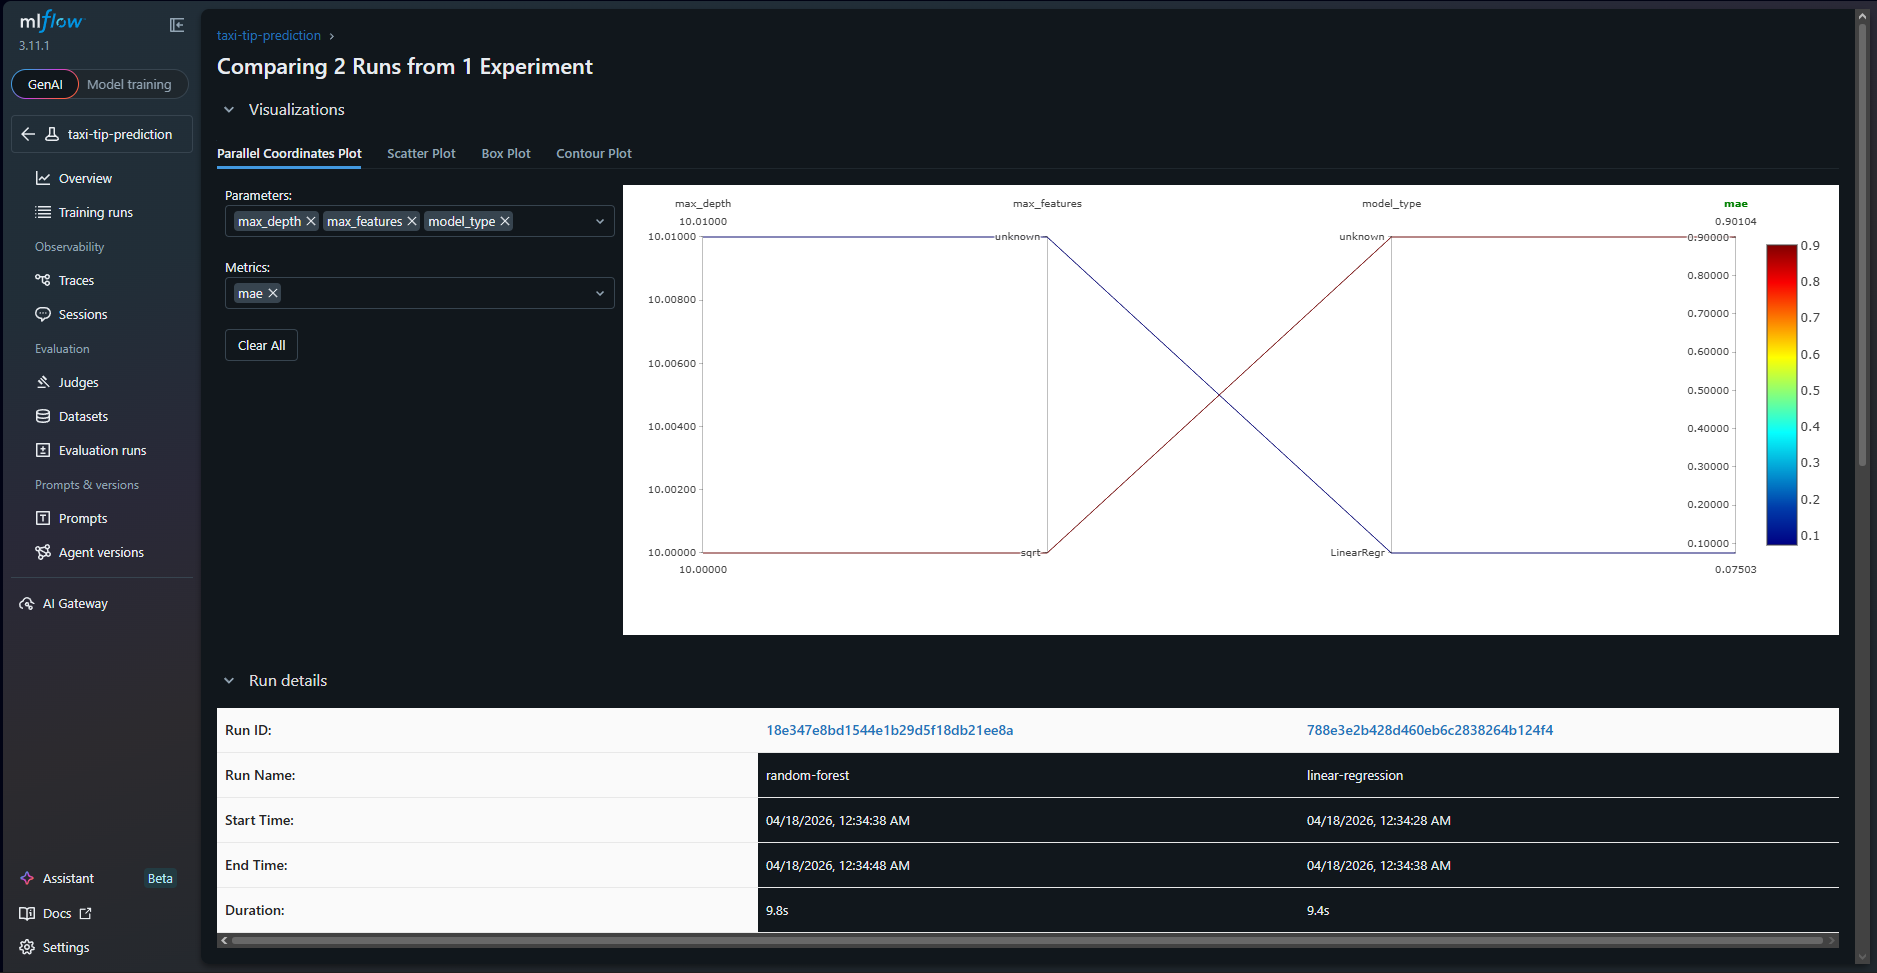

Identifying the Best Model

In [42]:
best_run = runs.loc[runs["metrics.mae"].idxmin()]
best_run_id = best_run["run_id"]

print(f"Best model: {best_run['tags.model_type']}")
print(f"MAE:  {best_run['metrics.mae']:.4f}")
print(f"RMSE: {best_run['metrics.rmse']:.4f}")
print(f"R²:   {best_run['metrics.r2']:.4f}")

Best model: LinearRegression
MAE:  0.0750
RMSE: 0.2739
R²:   0.9967


The Linear Regression model outperformed the Random Forest Regressor across all evaluation metrics, achieving an approximate MAE of 0.0750, RMSE of 0.2739 and R² of 0.9967. This strong performance suggests that the relationship between the selected trip features (fare_amount, trip_distance and pickup_hour) and tip_amount is largely linear in nature, meaning the added complexity of an ensemble method like Random Forest provided no additional benefit. The near-perfect R² score indicates that the Linear Regression model explains approximately 99.67% of the variance in tip_amount on the test set.

Registering the Best Performing Model

In [43]:
client = MlflowClient()

# Register the Best Model
result = mlflow.register_model(
    model_uri=f"runs:/{best_run_id}/model",
    name="taxi-tip-regressor"
)

# Adding an appropriate version description
client.update_model_version(
    name="taxi-tip-regressor",
    version=result.version,
    description=(
        f"Best model: {best_run['tags.model_type']} | "
        f"MAE={best_run['metrics.mae']:.4f} | "
        f"RMSE={best_run['metrics.rmse']:.4f} | "
        f"R2={best_run['metrics.r2']:.4f} | "
        f"Trained on NYC Yellow Taxi Trip Records, predicting tip_amount"
    )
)

print(f"Registered 'taxi-tip-regressor' version {result.version}")

Registered model 'taxi-tip-regressor' already exists. Creating a new version of this model...
2026/04/18 23:27:26 WARNING mlflow.tracking._model_registry.fluent: Run with id 4fb5da9aeebb4792a974595e942b8a50 has no artifacts at artifact path 'model', registering model based on models:/m-8ef5063f9b954777ba8df1e880452571 instead
2026/04/18 23:27:26 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 4


Registered 'taxi-tip-regressor' version 4


Created version '4' of model 'taxi-tip-regressor'.


Loading from Registry and Making a Sample Prediction

In [44]:
# Load the registered model
registered_model = mlflow.sklearn.load_model(f"models:/taxi-tip-regressor/{result.version}")

# Making a Sample Prediction
sample = X_test_processed[:1]
prediction = registered_model.predict(sample)
print(f"Sample predicted tip amount: ${prediction[0]:.2f}")

Sample predicted tip amount: $2.35


In [45]:
joblib.dump(registered_model, "models/registered_model.pkl")

print("\nRegistered model saved successfully!")


Registered model saved successfully!


# Part 2: Model Serving with FastAPI

Executing all Tests for the App using Pytest

In [46]:
!pytest test_app.py -v

============================= test session starts =============================
platform win32 -- Python 3.11.0, pytest-9.0.3, pluggy-1.6.0 -- C:\dev\LLM Project\MLOps-and-Model-Deployment\venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\dev\LLM Project\MLOps-and-Model-Deployment
plugins: anyio-4.13.0
collecting ... collected 10 items

test_app.py::test_predict_valid PASSED                                   [ 10%]
test_app.py::test_predict_batch PASSED                                   [ 20%]
test_app.py::test_predict_missing_field PASSED                           [ 30%]
test_app.py::test_predict_wrong_type PASSED                              [ 40%]
test_app.py::test_predict_out_of_range PASSED                            [ 50%]
test_app.py::test_health_check PASSED                                    [ 60%]
test_app.py::test_predict_zero_distance PASSED                           [ 70%]
test_app.py::test_predict_extreme_fare PASSED                            [ 80%]
test_app.py

Screenshot of all Pytest Tests Passing Successfully

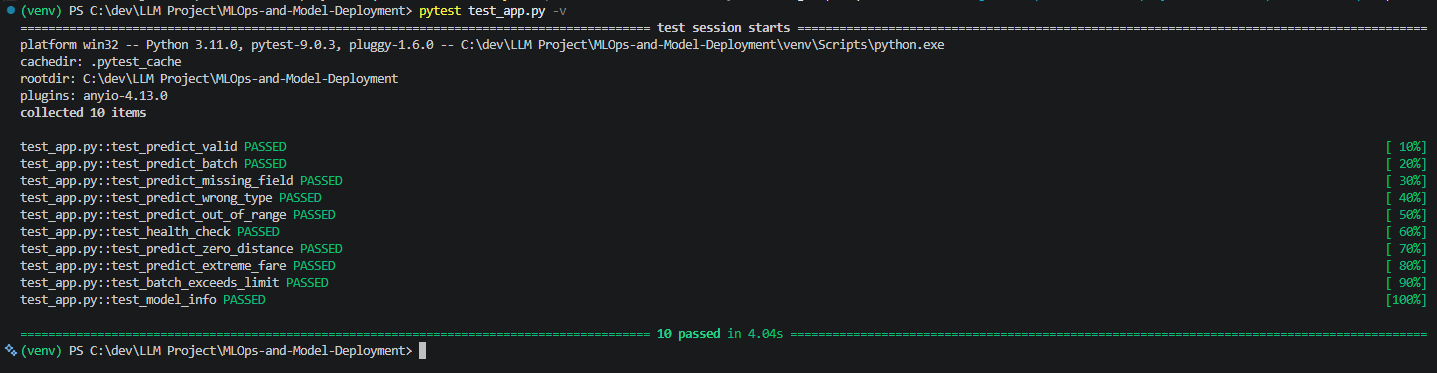

Screenshot of auto-generated Swagger UI documentation

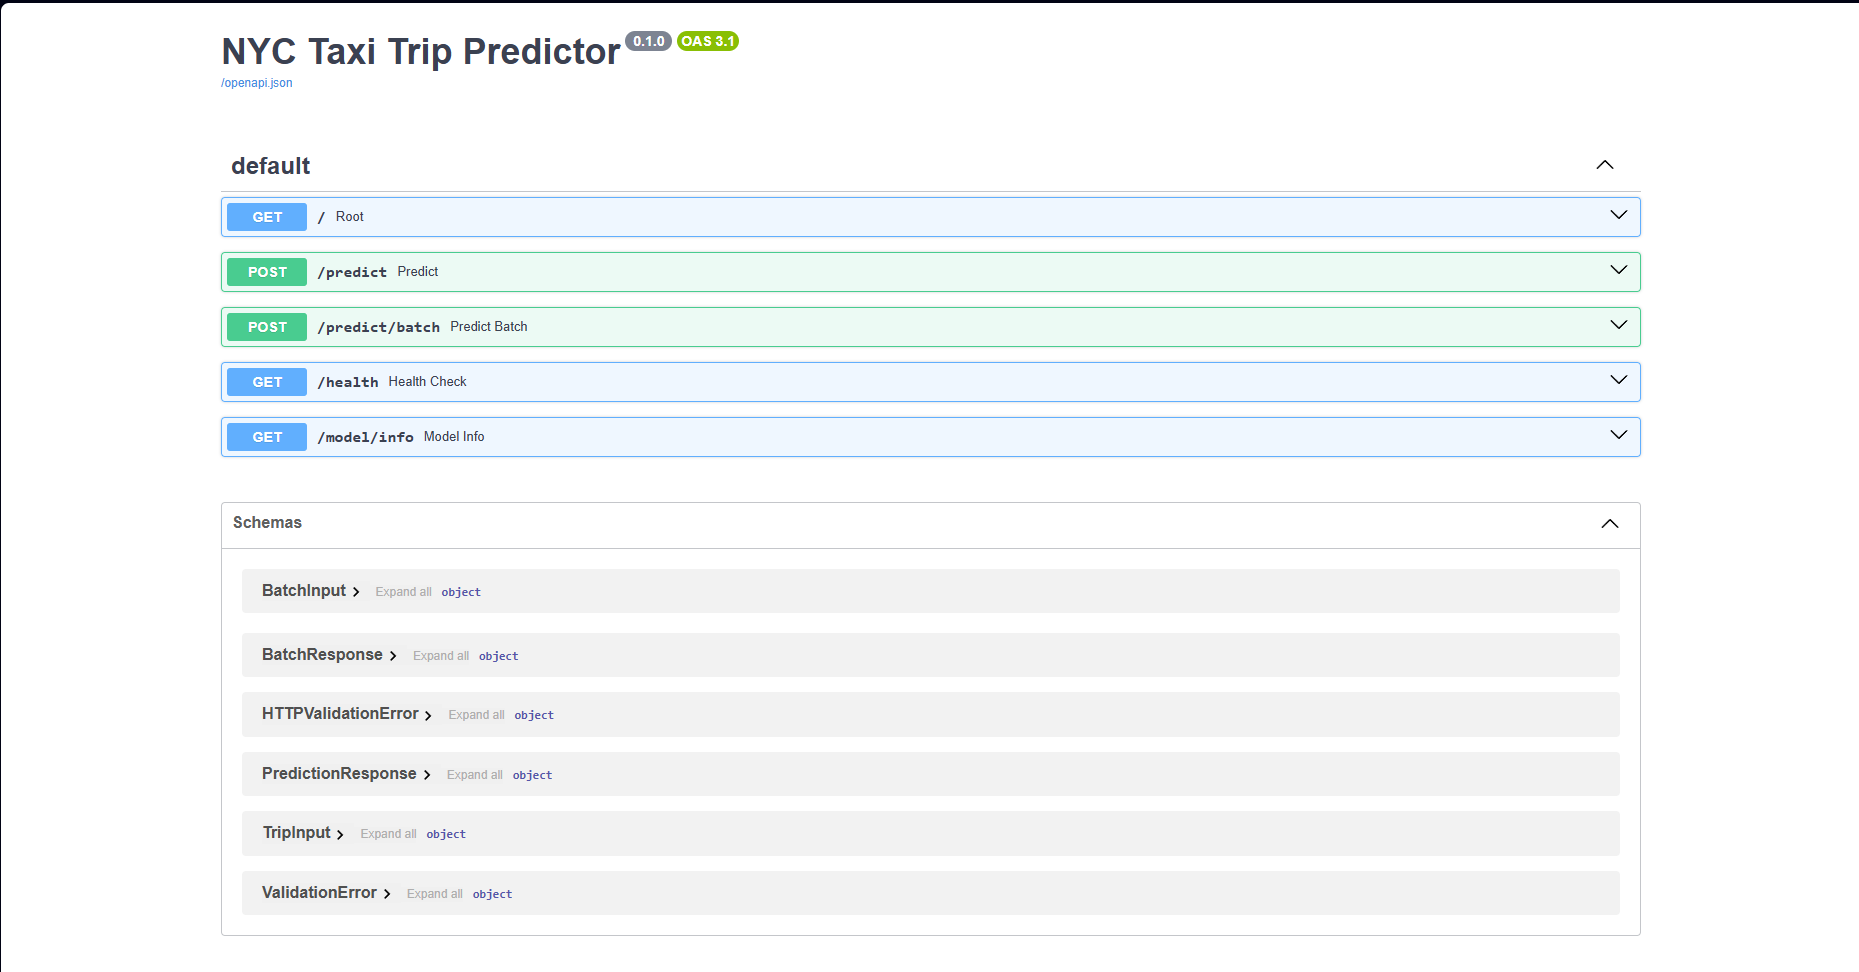

# Part 3: Containerization with Docker

Building the Docker Image adn Reporting Size

In [47]:
!docker build -t taxi-tip-api .

!docker images taxi-tip-api

#0 building with "desktop-linux" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 280B 0.0s done
#1 DONE 0.0s

#2 [auth] library/python:pull token for registry-1.docker.io
#2 DONE 0.0s

#3 [internal] load metadata for docker.io/library/python:3.11-slim
#3 DONE 0.8s

#4 [internal] load .dockerignore
#4 transferring context: 182B done
#4 DONE 0.0s

#5 [internal] load build context
#5 transferring context: 8.31kB 0.0s done
#5 DONE 0.0s

#6 [1/6] FROM docker.io/library/python:3.11-slim@sha256:233de06753d30d120b1a3ce359d8d3be8bda78524cd8f520c99883bfe33964cf
#6 resolve docker.io/library/python:3.11-slim@sha256:233de06753d30d120b1a3ce359d8d3be8bda78524cd8f520c99883bfe33964cf 0.0s done
#6 DONE 0.0s

#7 [3/6] COPY requirements.txt .
#7 CACHED

#8 [2/6] WORKDIR /app
#8 CACHED

#9 [4/6] RUN pip install --no-cache-dir -r requirements.txt
#9 CACHED

#10 [5/6] COPY app.py .
#10 CACHED

#11 [6/6] COPY models/ ./models/
#11 CACHED

#12 expor

IMAGE                 ID             DISK USAGE   CONTENT SIZE   EXTRA
taxi-tip-api:latest   4689a6bb7af5       1.57GB          348MB        


Screenshot of Docker Image Size

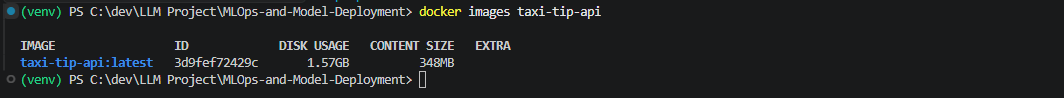

Running and Testing the Docker Container

In [48]:
# Start container in background
!docker run -d --name taxi-api -p 8000:8000 taxi-tip-api

# Wait for it to start
time.sleep(3)

response = requests.post(
    "http://localhost:8000/predict",
    json={
        "trip_distance": 3.5,
        "fare_amount": 14.5,
        "pickup_hour": 14,
        "passenger_count": 1,
        "trip_duration_minutes": 12.0,
        "total_amount": 18.8,
    }
)
print(response.json())

# Clean up
!docker stop taxi-api
!docker rm taxi-api

docker: Error response from daemon: failed to set up container networking: driver failed programming external connectivity on endpoint taxi-api (33cc842d5d83ba33b7057fdb2b213fd4158ba849c79df84d67e27254b24d0061): Bind for 0.0.0.0:8000 failed: port is already allocated

Run 'docker run --help' for more information


89e8ff6762136878431512c3f294d543b849fb96d4d12528831bbf790f743ba7
{'predicted_tip_amount': 5.37, 'model_version': '1', 'prediction_id': 'adaadb19-480c-4f5e-a32e-e38cdba4235b'}
taxi-api
taxi-api


Docker Composing

In [49]:
# Start services
!docker compose up -d --build

time.sleep(5)

# Make 3 prediction requests
for i in range(3):
    response = requests.post(
        "http://localhost:8000/predict",
        json={
            "trip_distance": 3.5 + i,
            "fare_amount": 14.5 + i,
            "pickup_hour": 14,
            "passenger_count": 1,
            "trip_duration_minutes": 12.0,
            "total_amount": 18.8 + i
        }
    )
    print(f"Prediction {i+1}: ${response.json()['predicted_tip_amount']}")

# Shut down cleanly
!docker compose down

 Image mlops-and-model-deployment-api Building 
 Image mlops-and-model-deployment-api Built 
 Container mlops-and-model-deployment-api-1 Recreate 
 Container mlops-and-model-deployment-api-1 Recreated 
 Container mlops-and-model-deployment-api-1 Starting 
 Container mlops-and-model-deployment-api-1 Started 


#1 [internal] load local bake definitions
#1 reading from stdin 575B done
#1 DONE 0.0s

#2 [internal] load build definition from Dockerfile
#2 transferring dockerfile: 280B 0.0s done
#2 DONE 0.0s

#3 [internal] load metadata for docker.io/library/python:3.11-slim
#3 DONE 0.2s

#4 [internal] load .dockerignore
#4 transferring context: 182B done
#4 DONE 0.0s

#5 [internal] load build context
#5 transferring context: 180B done
#5 DONE 0.0s

#6 [1/6] FROM docker.io/library/python:3.11-slim@sha256:233de06753d30d120b1a3ce359d8d3be8bda78524cd8f520c99883bfe33964cf
#6 resolve docker.io/library/python:3.11-slim@sha256:233de06753d30d120b1a3ce359d8d3be8bda78524cd8f520c99883bfe33964cf 0.0s done
#6 DONE 0.1s

#7 [3/6] COPY requirements.txt .
#7 CACHED

#8 [4/6] RUN pip install --no-cache-dir -r requirements.txt
#8 CACHED

#9 [5/6] COPY app.py .
#9 CACHED

#10 [2/6] WORKDIR /app
#10 CACHED

#11 [6/6] COPY models/ ./models/
#11 CACHED

#12 exporting to image
#12 exporting layers done
#12 exporting man

 Container mlops-and-model-deployment-api-1 Stopping 
 Container mlops-and-model-deployment-api-1 Stopped 
 Container mlops-and-model-deployment-api-1 Removing 
 Container mlops-and-model-deployment-api-1 Removed 
 Network mlops-and-model-deployment_default Removing 
 Network mlops-and-model-deployment_default Removed 


## Container Size & Configuration

### Image Size
| Field         | Value  |
|---------------|--------|
| Content Size  | 348MB  |
| Disk Usage    | 1.57GB (includes shared Docker layers) |
| Base Image    | python:3.11-slim                        |

### Requirements to Run
- Docker Desktop installed and running
- Python 3.11+

### Running the Project
1. Clone the repository
2. Build the image:
```bash
   docker build -t taxi-tip-api .
```
3. Run the container:
```bash
   docker run -d --name taxi-api -p 8000:8000 taxi-tip-api
```
4. Or use Docker Compose:
```bash
   docker compose up --build
```

### Environment Variables
| Variable           | Default                          | Description              |
|--------------------|----------------------------------|--------------------------|
| MODEL_PATH         | /app/models/registered_model.pkl | Path to the trained model |
| PREPROCESSOR_PATH  | /app/models/preprocessor.pkl     | Path to the preprocessor |

### Ports
| Service | Host Port | Container Port |
|---------|-----------|----------------|
| API     | 8000      | 8000           |

### Endpoints
| Endpoint         | Method | Description              |
|------------------|--------|--------------------------|
| /predict         | POST   | Single trip prediction   |
| /predict/batch   | POST   | Batch predictions        |
| /health          | GET    | API health status        |
| /model/info      | GET    | Model metadata           |

# AI Disclosure

Claude was used as the only AI tool for this assignment as many guides were provided. Claude was used for mainly explaing how many of the features adn how to use the concepts in this assignment as well for the README documentation.